# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

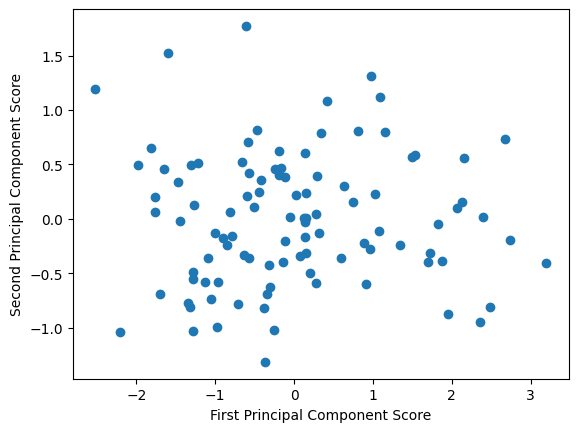

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [3]:
import seaborn as sns

# Load the data using the relative path from your notebook location
file_path = 'datasets/risk_factors_cervical_cancer.csv'
df = pd.read_csv(file_path, na_values=["?"])

# Impute missing values with the median for numerical stability
df = df.fillna(df.median())

# Display the first few rows to confirm it loaded correctly
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,4.0,3.0,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0


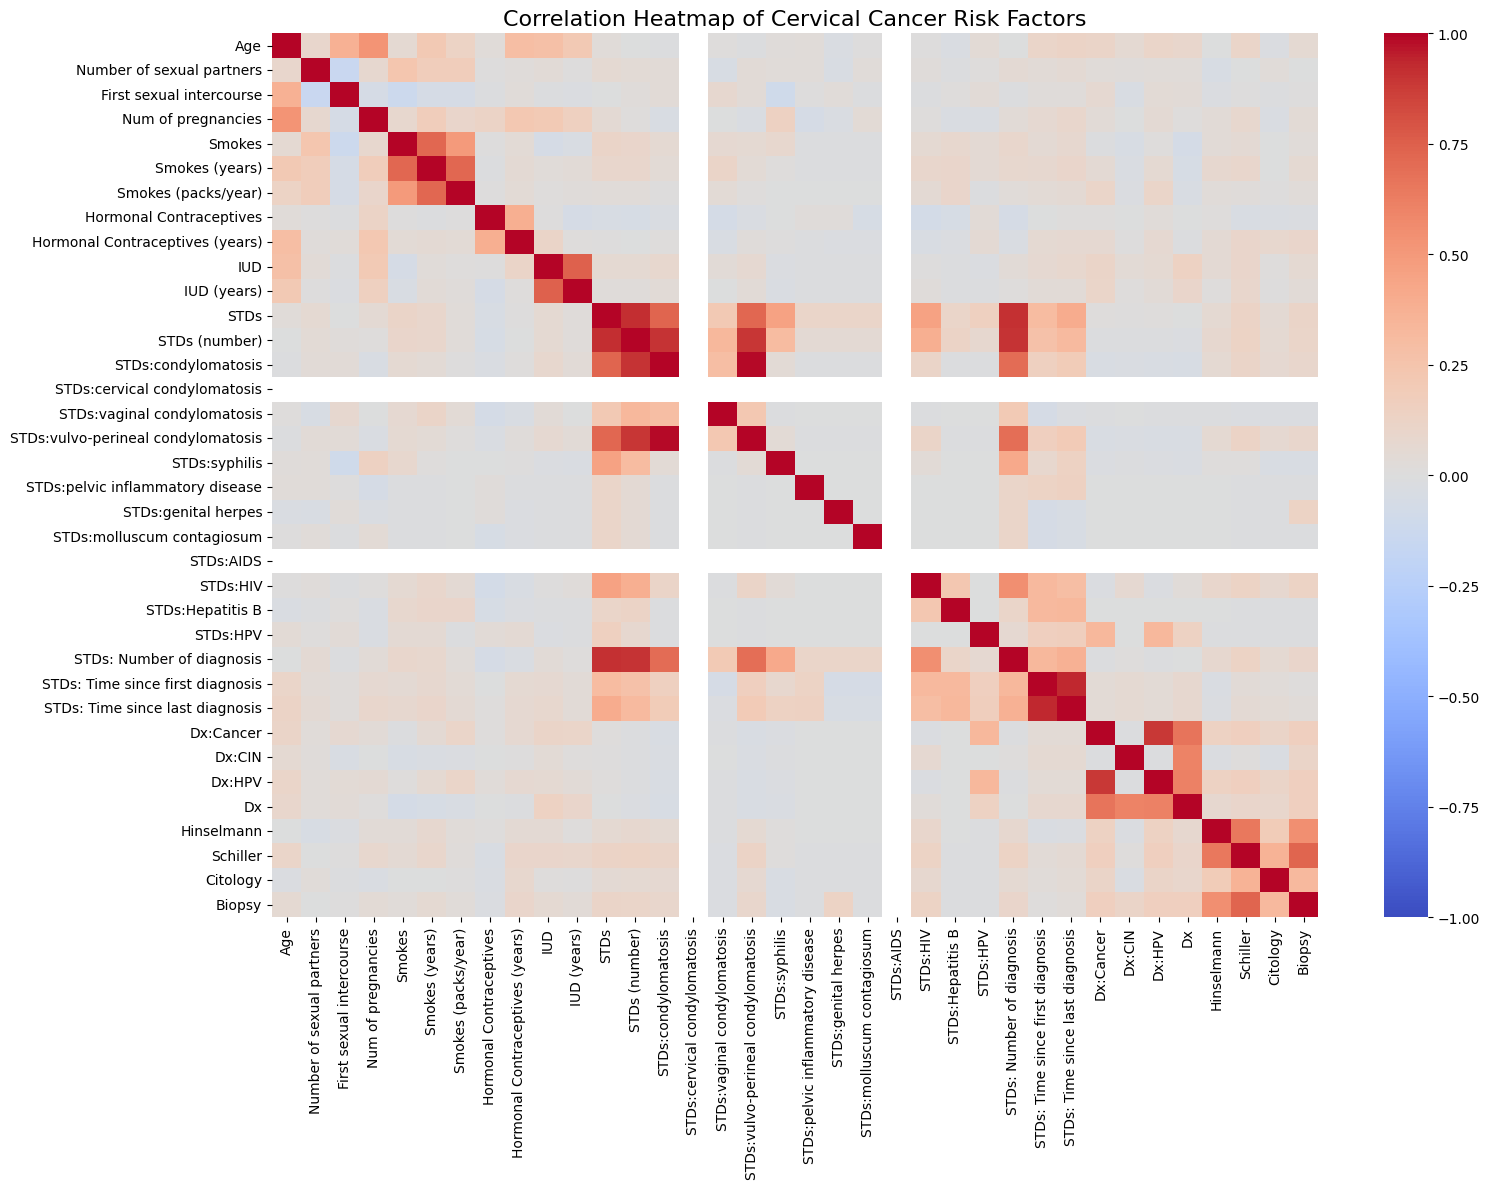

Top Absolute Correlations:
STDs:condylomatosis                 STDs:vulvo-perineal condylomatosis    0.987964
STDs:vulvo-perineal condylomatosis  STDs:condylomatosis                   0.987964
STDs: Time since first diagnosis    STDs: Time since last diagnosis       0.935614
STDs: Time since last diagnosis     STDs: Time since first diagnosis      0.935614
STDs (number)                       STDs                                  0.919625
STDs                                STDs (number)                         0.919625
STDs: Number of diagnosis           STDs                                  0.907805
STDs                                STDs: Number of diagnosis             0.907805
STDs:condylomatosis                 STDs (number)                         0.900245
STDs (number)                       STDs:condylomatosis                   0.900245
dtype: float64


In [4]:
plt.figure(figsize=(16, 12))
# Calculate the correlation matrix
corr_matrix = df.corr()

# Draw the heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Cervical Cancer Risk Factors', fontsize=16)
plt.tight_layout()
plt.show()

# Print the highest correlations to help with regression later
print("Top Absolute Correlations:")
s = corr_matrix.unstack().abs().sort_values(ascending=False)
print(s[s < 1.0].head(10)) # Filter out self-correlations (1.0)

In [23]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

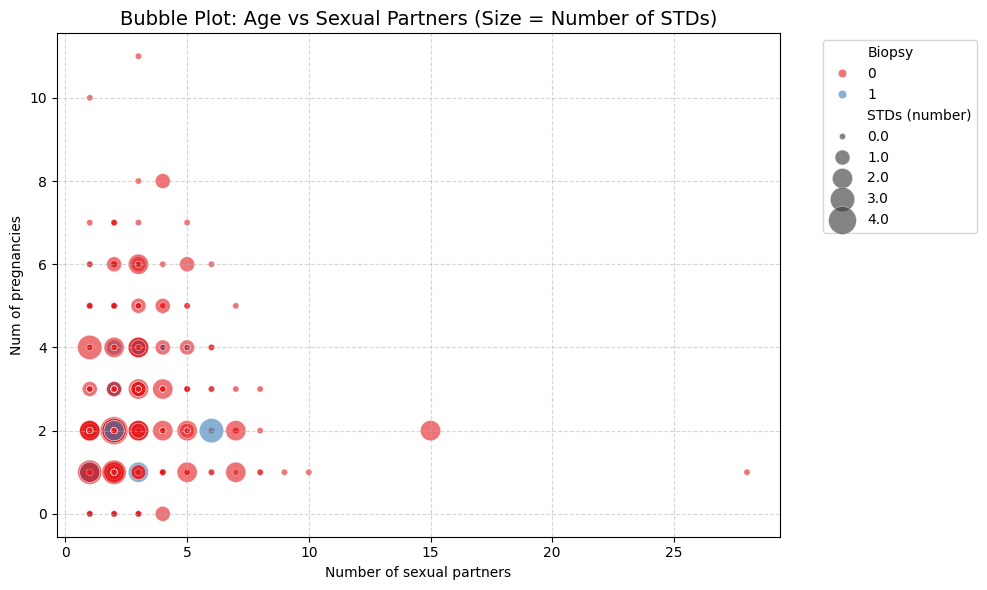

In [20]:
plt.figure(figsize=(10, 6))
# Using Age, Number of sexual partners, and sizing by Smokes (years)
bubble = sns.scatterplot(
    data=df, 
    x='Number of sexual partners', 
    y='Num of pregnancies', 
    size='STDs (number)', 
    sizes=(20, 400), 
    alpha=0.6, 
    hue='Biopsy', # Color coding by whether they had a biopsy
    palette='Set1'
)
plt.title('Bubble Plot: Age vs Sexual Partners (Size = Number of STDs)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

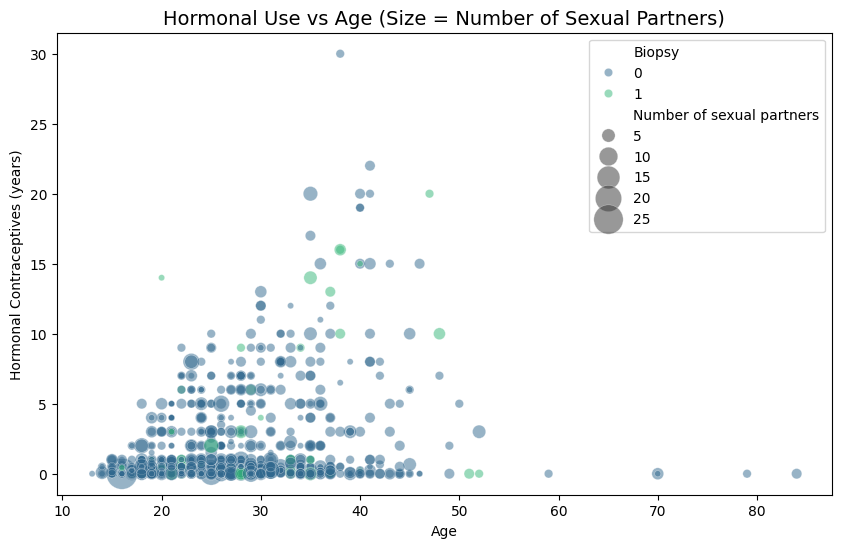

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Hormonal Contraceptives (years)', 
    size='Smokes (packs/year)', 
    sizes=(20, 500), 
    alpha=0.5, 
    hue='Biopsy', 
    palette='viridis'
)
plt.title('Hormonal Use vs Age (Size = Smoking Intensity)', fontsize=14)
plt.show()

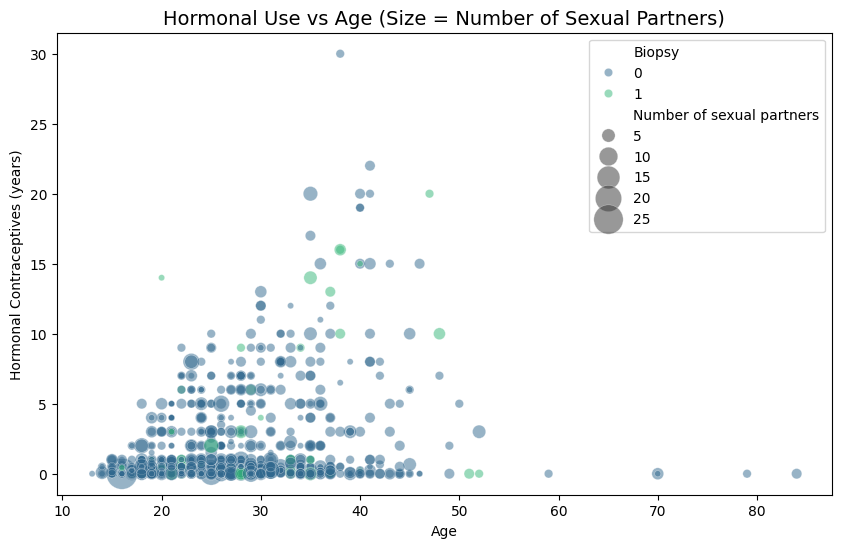

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Hormonal Contraceptives (years)', 
    size='Number of sexual partners', 
    sizes=(20, 500), 
    alpha=0.5, 
    hue='Biopsy', 
    palette='viridis'
)
plt.title('Hormonal Use vs Age (Size = Number of Sexual Partners)', fontsize=14)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Hormonal Contraceptives (years)', 
    size='Smokes (packs/year)', 
    sizes=(20, 500), 
    alpha=0.5, 
    hue='Biopsy', 
    palette='viridis'
)
plt.title('Hormonal Use vs Age (Size = Smoking Intensity)', fontsize=14)
plt.show()

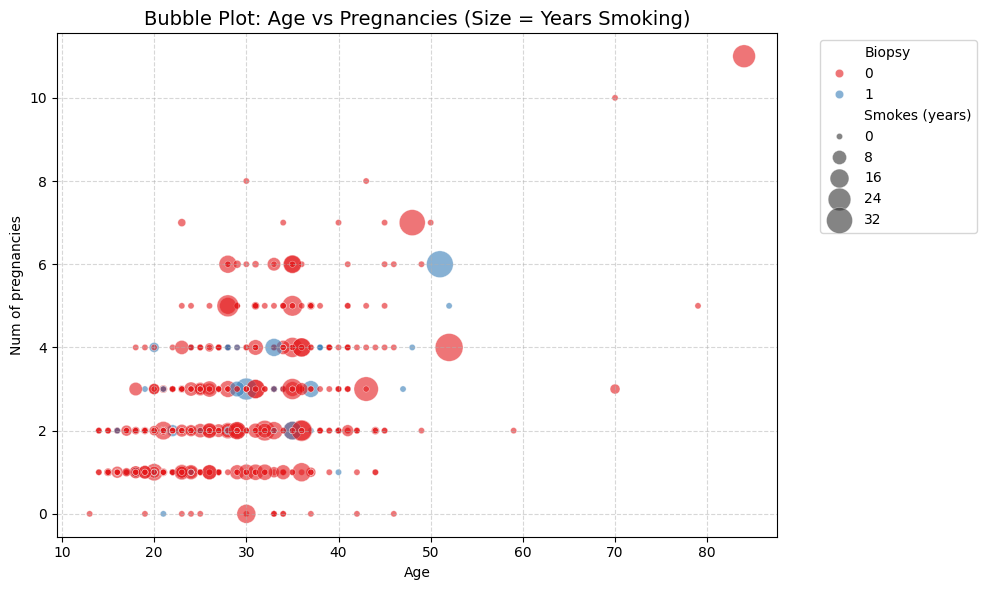

In [26]:
plt.figure(figsize=(10, 6))
# Using Age, Number of sexual partners, and sizing by Smokes (years)
bubble = sns.scatterplot(
    data=df, 
    x='Age', 
    y='Num of pregnancies', 
    size='Smokes (years)', 
    sizes=(20, 400), 
    alpha=0.6, 
    hue='Biopsy', # Color coding by whether they had a biopsy
    palette='Set1'
)
plt.title('Bubble Plot: Age vs Pregnancies (Size = Years Smoking)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

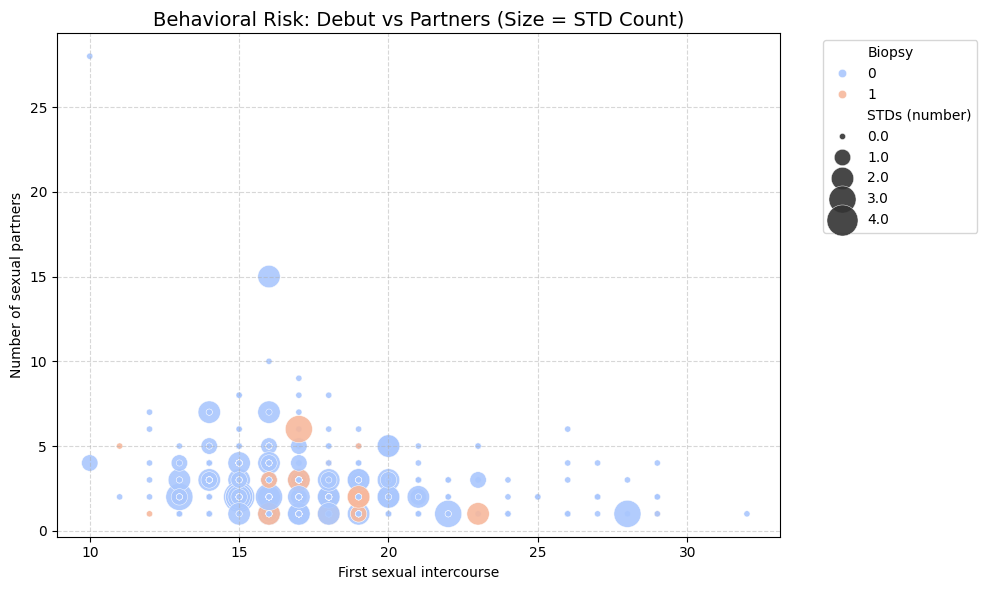

In [30]:
plt.figure(figsize=(10, 6))

# Plotting behavioral risk factors
sns.scatterplot(
    data=df, 
    x='First sexual intercourse', 
    y='Number of sexual partners', 
    size='STDs (number)', 
    sizes=(20, 500), 
    alpha=0.9, 
    hue='Biopsy', 
    palette='coolwarm' # Using a different palette to easily distinguish your charts
)

plt.title('Behavioral Risk: Debut vs Partners (Size = STD Count)', fontsize=14)
# Moving the legend outside the plot so it doesn't cover your data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Variance captured by the 1st Principal Component: 16.89%
Variance captured by the 2nd Principal Component: 9.79%


/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/wadieabbas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encounter

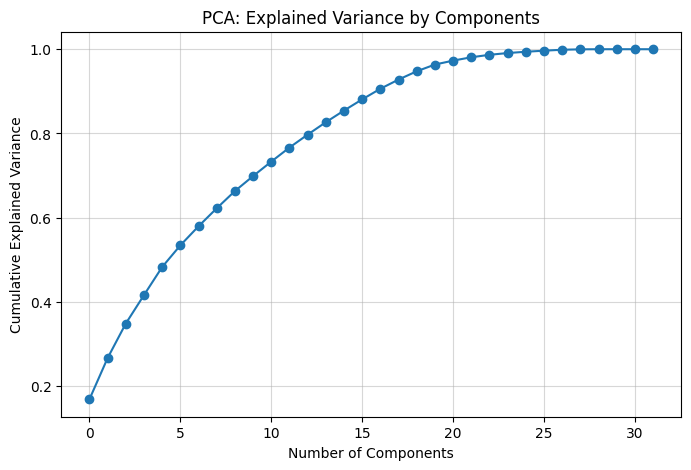

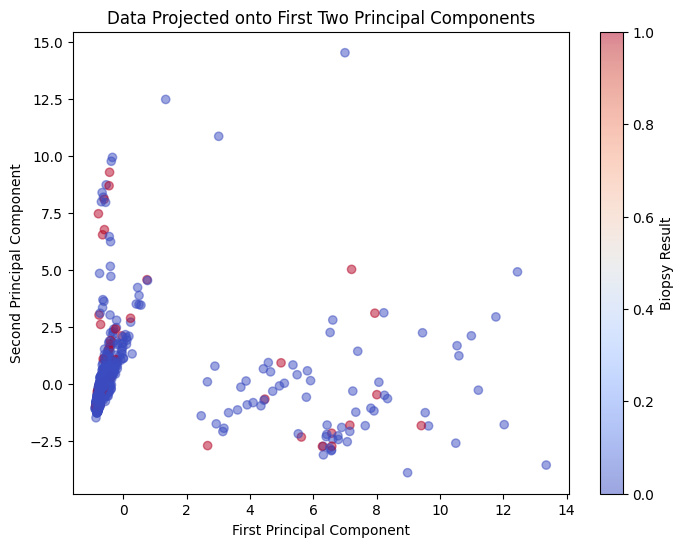

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Separate features from the typical target variables
X = df.drop(columns=['Hinselmann', 'Schiller', 'Citology', 'Biopsy'])
y = df['Biopsy'] 

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate variance captured by the first principal component
var_pc1 = pca.explained_variance_ratio_[0] * 100
print(f"Variance captured by the 1st Principal Component: {var_pc1:.2f}%")
print(f"Variance captured by the 2nd Principal Component: {pca.explained_variance_ratio_[1] * 100:.2f}%")

# Plot the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Explained Variance by Components')
plt.grid(True, alpha=0.5)
plt.show()

# Plotting the data projected onto the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c=y, cmap='coolwarm')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Data Projected onto First Two Principal Components')
plt.colorbar(label='Biopsy Result')
plt.show()

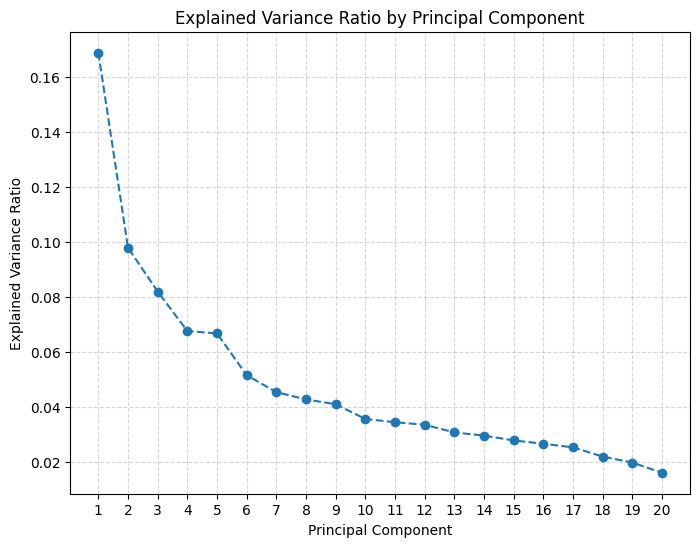

In [22]:

# Adjust the x-axis to integers and align vertical grid lines
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_[:20]) + 1), pca.explained_variance_ratio_[:20], marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(pca.explained_variance_ratio_[:20]) + 1))  # Set x-axis to integers
plt.grid(linestyle='--', alpha=0.5)  # Align vertical grid lines
plt.show()

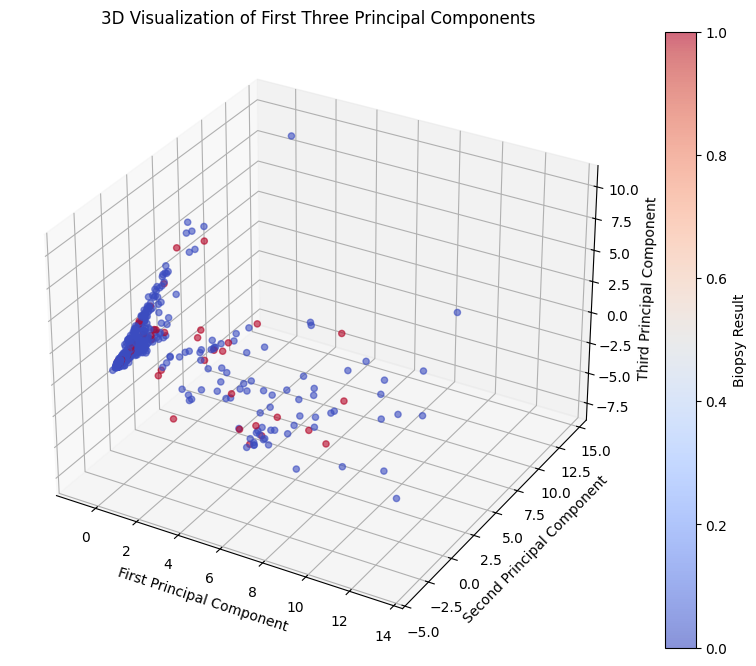

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the first three principal components
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.6, c=y, cmap='coolwarm')
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_zlabel('Third Principal Component')
ax.set_title('3D Visualization of First Three Principal Components')
plt.colorbar(ax.collections[0], label='Biopsy Result')
plt.show()

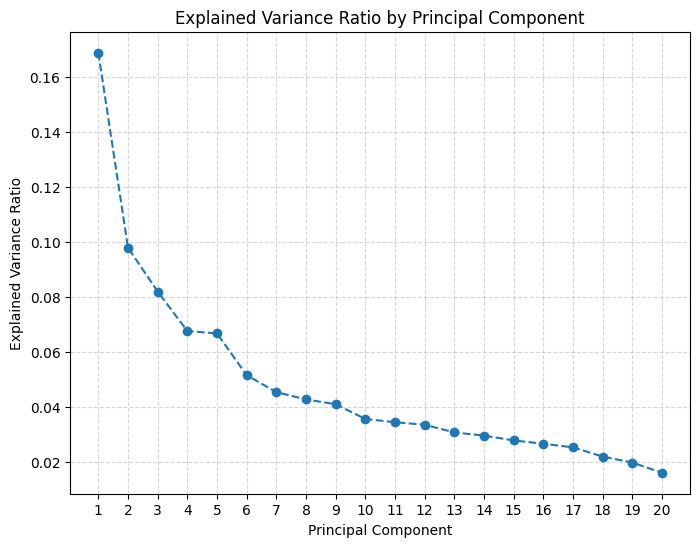